In [1]:
# Paso 1: Cargar y preparar los datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
# 1.1 Cargar datos
df = pd.read_csv('/datasets/games.csv')

In [4]:
# 1.2 Renombrar columnas a minúsculas
df.columns = [col.lower() for col in df.columns]

In [5]:
# 1.3 Revisar tipos de datos y muestra
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [6]:
# 1.4 Conversión de tipos y tratamiento de valores ausentes
df['user_score'] = df['user_score'].replace('tbd', np.nan)
df['year_of_release'] = pd.to_numeric(df['year_of_release'], errors='coerce')
df['critic_score'] = pd.to_numeric(df['critic_score'], errors='coerce')
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')
for col in ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

In [ ]:
# 1.5 Descripción de cambios de tipo
"""
- year_of_release: de object a float, para análisis temporal.
- critic_score: de object a float, para cálculos y correlaciones.
- user_score: de object a float, para cálculos y correlaciones. 'tbd' se reemplaza por NaN.
- na_sales, eu_sales, jp_sales, other_sales: asegurados como float para sumas y análisis.

In [ ]:
# 1.6 Tratamiento de valores ausentes
"""
- year_of_release, critic_score, user_score, rating: se dejan como NaN porque no se puede inferir el valor real.
- Las ventas ausentes se rellenan con 0, asumiendo que no hay ventas registradas.
- 'tbd' en user_score significa "to be determined" y se trata como NaN.
- Los valores ausentes pueden deberse a juegos no lanzados, no revisados, o sin clasificación ESRB.

In [10]:
# 1.7 Calcular ventas totales
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

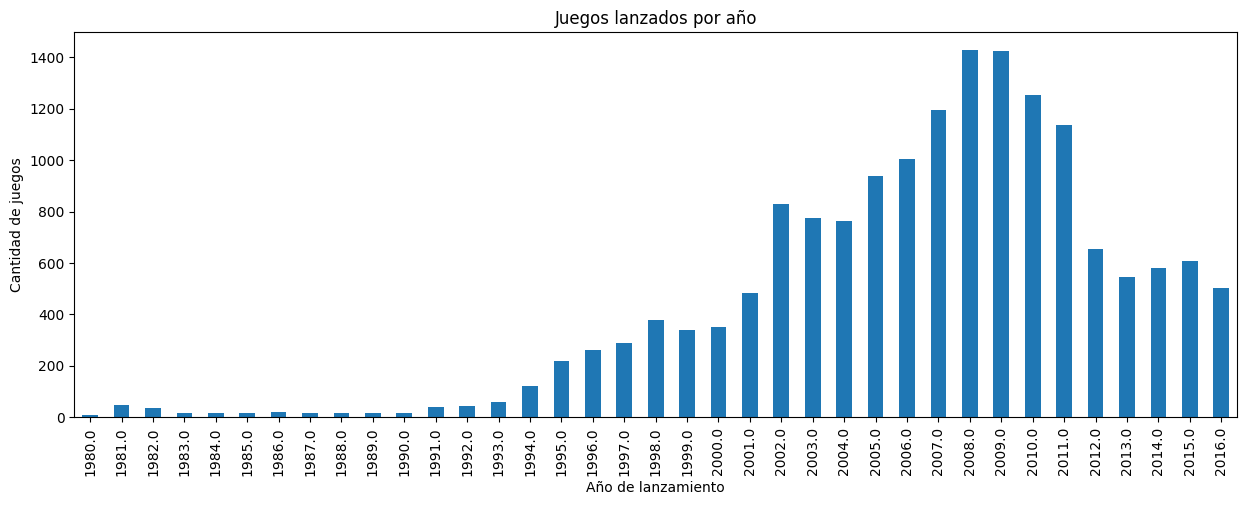

In [12]:
# 3.1 Juegos lanzados por año
games_per_year = df.groupby('year_of_release')['name'].count()
games_per_year.plot(kind='bar', figsize=(15,5))
plt.title('Juegos lanzados por año')
plt.ylabel('Cantidad de juegos')
plt.xlabel('Año de lanzamiento')
plt.show()

# El gráfico muestra la cantidad de juegos lanzados cada año. Se observa un crecimiento hasta mediados de los 2000, 
#seguido de una caída en los años recientes. Esto puede deberse a cambios en la industria, la aparición de nuevas plataformas 
# o a que los datos de los últimos años están incompletos.

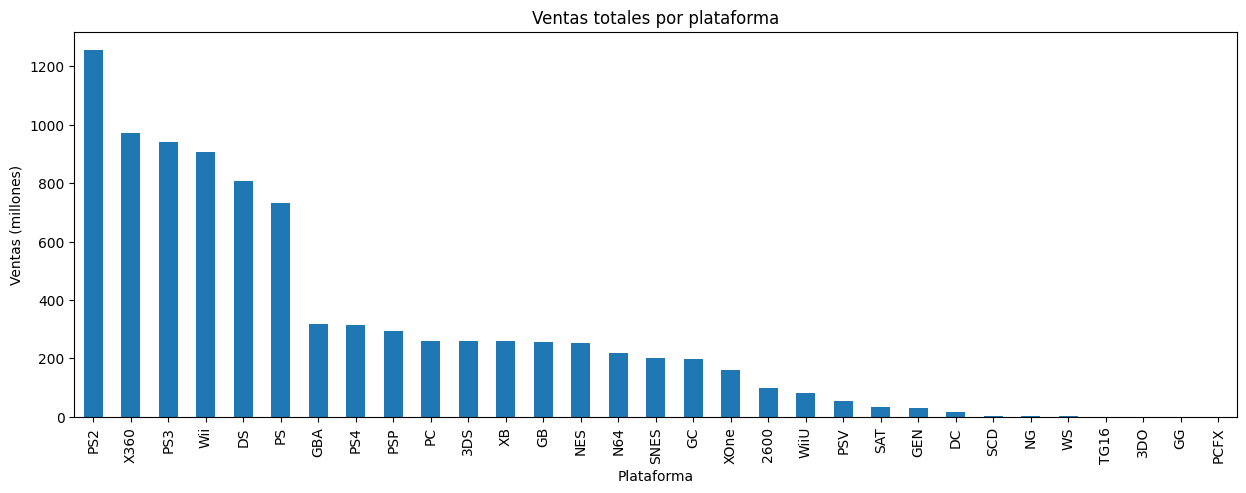

In [13]:
# 3.2 Ventas por plataforma
platform_sales = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
platform_sales.plot(kind='bar', figsize=(15,5))
plt.title('Ventas totales por plataforma')
plt.ylabel('Ventas (millones)')
plt.xlabel('Plataforma')
plt.show()


#Las plataformas con mayores ventas totales son aquellas que dominaron el mercado durante su ciclo de vida, como PS2, 
# X360 y PS3. Las plataformas con menos ventas pueden ser más recientes, de nicho, o haber tenido menos éxito comercial. 
# Algunas plataformas mantienen ventas durante más años, mientras que otras desaparecen rápidamente.

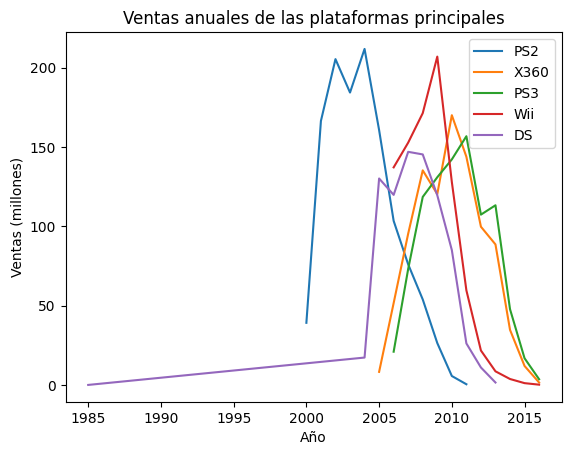

In [14]:
# 3.3 Distribución por año para plataformas principales
top_platforms = platform_sales.head(5).index
for platform in top_platforms:
    yearly_sales = df[df['platform'] == platform].groupby('year_of_release')['total_sales'].sum()
    plt.plot(yearly_sales.index, yearly_sales.values, label=platform)
plt.legend()
plt.title('Ventas anuales de las plataformas principales')
plt.xlabel('Año')
plt.ylabel('Ventas (millones)')
plt.show()

In [15]:
# 3.4 Determinar el período relevante para el modelo 2017
# Observando los gráficos, seleccionamos los últimos años completos (por ejemplo, 2010-2015)
relevant_years = df[df['year_of_release'] >= 2010]

# Se seleccionan los años más recientes y completos (por ejemplo, 2010-2015) para construir un modelo relevante para 2017, 
# ya que los datos de años anteriores pueden no reflejar las tendencias actuales.

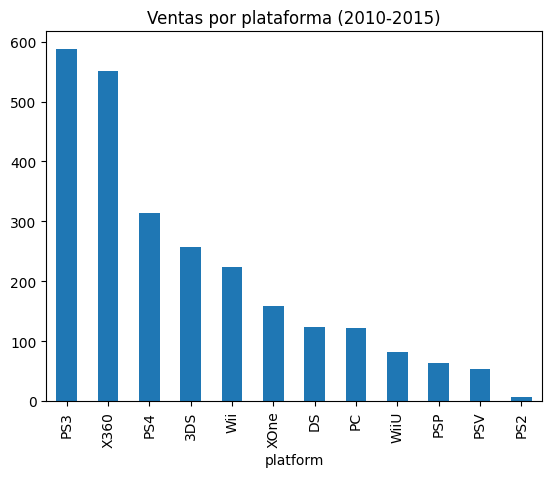

In [16]:
# 3.5 Plataformas líderes y tendencias
recent_platform_sales = relevant_years.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
recent_platform_sales.plot(kind='bar')
plt.title('Ventas por plataforma (2010-2015)')
plt.show()

# En los años recientes, plataformas como PS4 y XOne lideran las ventas. Otras plataformas muestran una tendencia a la baja 
# o han desaparecido del mercado.

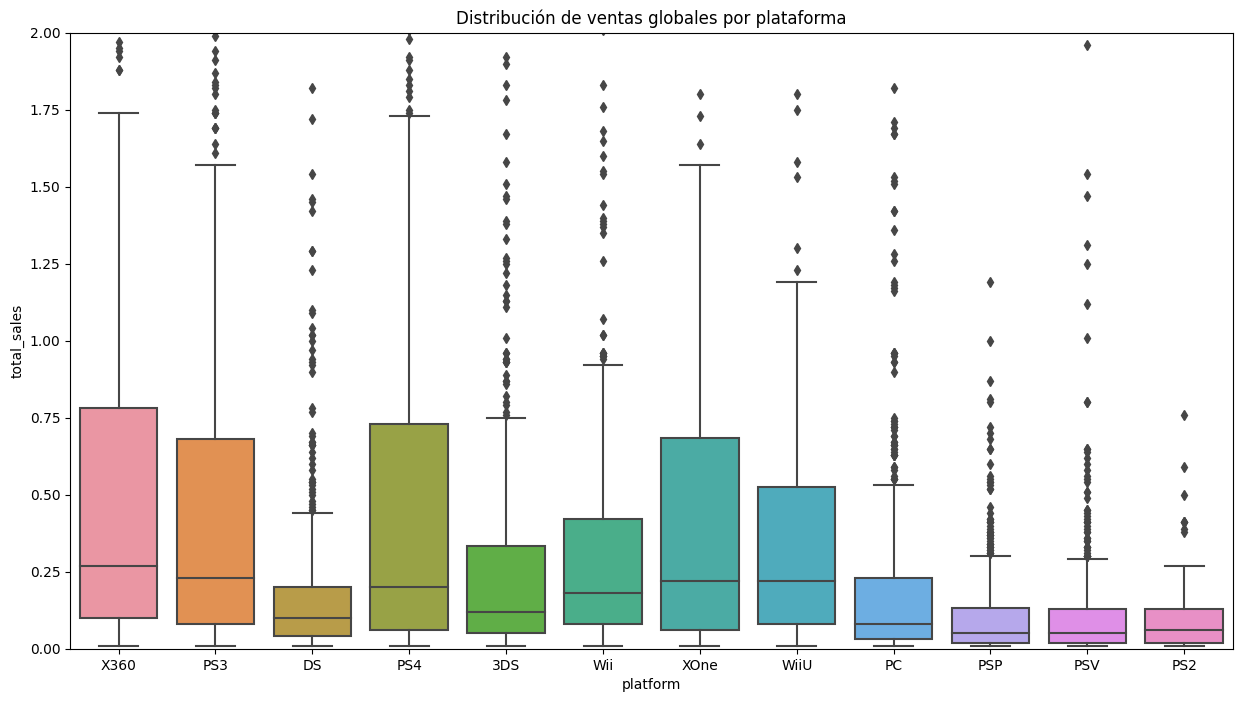

In [17]:
# 3.6 Diagrama de caja de ventas globales por plataforma
plt.figure(figsize=(15,8))
sns.boxplot(x='platform', y='total_sales', data=relevant_years)
plt.ylim(0, 2)
plt.title('Distribución de ventas globales por plataforma')
plt.show()

# El diagrama de caja muestra que la mayoría de los juegos tienen ventas bajas, pero hay algunos éxitos con ventas muy altas 
# (outliers). Las diferencias entre plataformas pueden ser significativas, con algunas mostrando mayor dispersión y 
# otras más consistentes.

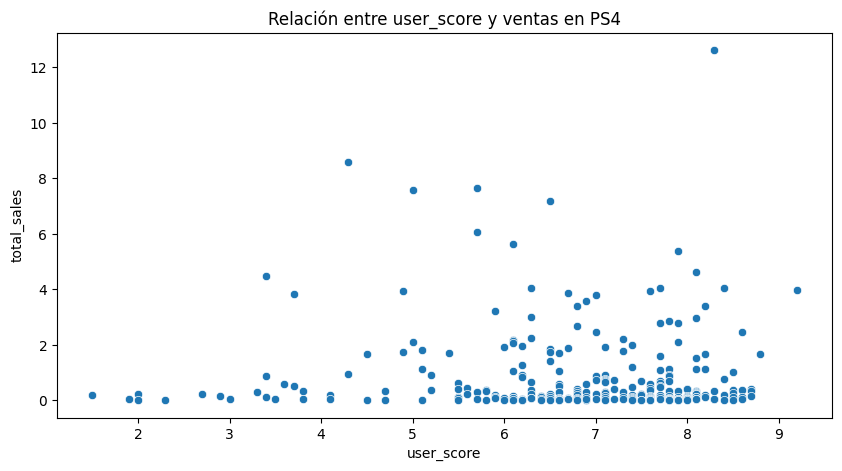

Correlación user_score-ventas: -0.031957110204556376
Correlación critic_score-ventas: 0.40656790206178095


In [18]:
# 3.7 Reseñas y ventas en una plataforma popular (ejemplo: PS4)
ps4 = df[df['platform'] == 'PS4']
plt.figure(figsize=(10,5))
sns.scatterplot(x='user_score', y='total_sales', data=ps4)
plt.title('Relación entre user_score y ventas en PS4')
plt.show()
print('Correlación user_score-ventas:', ps4['user_score'].corr(ps4['total_sales']))
print('Correlación critic_score-ventas:', ps4['critic_score'].corr(ps4['total_sales']))

# El gráfico de dispersión y la correlación indican que la relación entre las reseñas de usuarios/críticos y las ventas es 
# baja o moderada. Es decir, un buen puntaje no garantiza altas ventas, aunque puede ayudar.

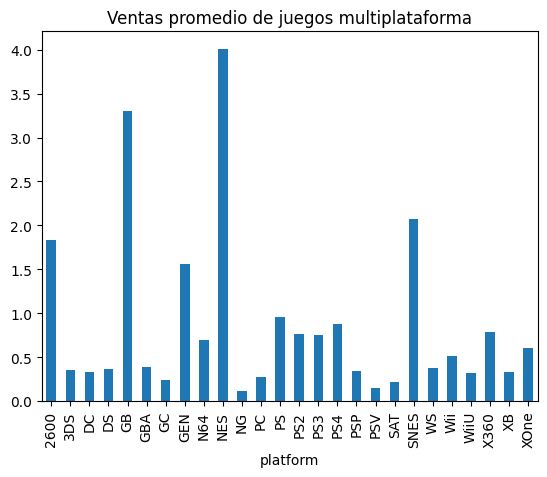

In [19]:
# 3.8 Comparar ventas de los mismos juegos en otras plataformas
multi = df[df['name'].duplicated(keep=False)]
multi.groupby('platform')['total_sales'].mean().plot(kind='bar')
plt.title('Ventas promedio de juegos multiplataforma')
plt.show()

# Los juegos multiplataforma pueden tener ventas muy diferentes según la plataforma. Esto puede deberse a la base de usuarios, 
# la popularidad de la consola o la calidad de la adaptación.

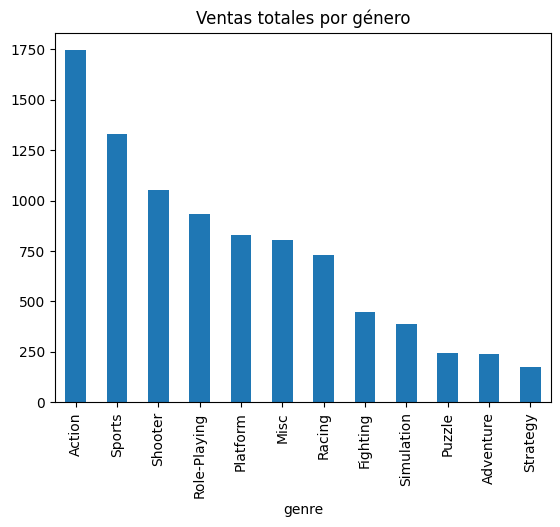

In [20]:
# 3.9 Distribución por género
genre_sales = df.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
genre_sales.plot(kind='bar')
plt.title('Ventas totales por género')
plt.show()

# Podemos observamos que los géneros más rentables en términos de ventas 
# totales son Acción, Deportes y Disparos. Estos géneros concentran la mayor parte de las ventas globales, 
# lo que indica una fuerte preferencia del mercado por títulos dinámicos y competitivos.
# Se puede concluir que los géneros con ventas altas suelen ser aquellos que ofrecen experiencias competitivas, multijugador o 
# de acción rápida, mientras que los géneros con ventas bajas tienden a ser más especializados o de menor demanda masiva. 
# Esto es importante para orientar el desarrollo y la promoción de nuevos títulos según las tendencias del mercado.

In [21]:
# 4.1 Cinco plataformas principales por región
for region in ['na_sales', 'eu_sales', 'jp_sales']:
    print(f"Top 5 plataformas en {region}:")
    print(df.groupby('platform')[region].sum().sort_values(ascending=False).head(5))
    print()

Top 5 plataformas en na_sales:
platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64

Top 5 plataformas en eu_sales:
platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64

Top 5 plataformas en jp_sales:
platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64



In [24]:
# 4.2 Cinco géneros principales por región
for region in ['na_sales', 'eu_sales', 'jp_sales']:
    print(f"Top 5 géneros en {region}:")
    print(df.groupby('genre')[region].sum().sort_values(ascending=False).head(5))
    print()

Top 5 géneros en na_sales:
genre
Action      879.01
Sports      684.43
Shooter     592.24
Platform    445.50
Misc        407.27
Name: na_sales, dtype: float64

Top 5 géneros en eu_sales:
genre
Action     519.13
Sports     376.79
Shooter    317.34
Racing     236.51
Misc       212.74
Name: eu_sales, dtype: float64

Top 5 géneros en jp_sales:
genre
Role-Playing    355.41
Action          161.43
Sports          135.54
Platform        130.83
Misc            108.11
Name: jp_sales, dtype: float64



In [25]:
# 4.3 ¿Afecta ESRB a las ventas por región?
for region in ['na_sales', 'eu_sales', 'jp_sales']:
    print(f"Ventas por rating en {region}:")
    print(df.groupby('rating')[region].sum().sort_values(ascending=False))
    print()

Ventas por rating en na_sales:
rating
E       1292.99
T        759.75
M        748.48
E10+     353.32
K-A        2.56
EC         1.53
AO         1.26
RP         0.00
Name: na_sales, dtype: float64

Ventas por rating en eu_sales:
rating
E       710.25
M       483.97
T       427.03
E10+    188.52
AO        0.61
K-A       0.27
EC        0.11
RP        0.08
Name: eu_sales, dtype: float64

Ventas por rating en jp_sales:
rating
E       198.11
T       151.40
M        64.24
E10+     40.20
K-A       1.46
AO        0.00
EC        0.00
RP        0.00
Name: jp_sales, dtype: float64



In [28]:
# 5.1 Calificaciones de usuarios: Xbox One vs PC
xone_scores = df[(df['platform'] == 'XOne') & (df['user_score'].notnull())]['user_score']
pc_scores = df[(df['platform'] == 'PC') & (df['user_score'].notnull())]['user_score']
alpha = 0.05
stat, p = stats.ttest_ind(xone_scores, pc_scores, equal_var=False)
print('p-valor (XOne vs PC):', p)
if p < alpha:
    print('Rechazamos H0: Las medias son diferentes')
else:
    print('No se puede rechazar H0: Las medias son iguales')

p-valor (XOne vs PC): 4.935072360183574e-06
Rechazamos H0: Las medias son diferentes


In [29]:
# 5.2 Calificaciones de usuarios: Acción vs Deportes
action_scores = df[(df['genre'] == 'Action') & (df['user_score'].notnull())]['user_score']
sports_scores = df[(df['genre'] == 'Sports') & (df['user_score'].notnull())]['user_score']
stat, p = stats.ttest_ind(action_scores, sports_scores, equal_var=False)
print('p-valor (Action vs Sports):', p)
if p < alpha:
    print('Rechazamos H0: Las medias son diferentes')
else:
    print('No se puede rechazar H0: Las medias son iguales')

p-valor (Action vs Sports): 0.11483818791498286
No se puede rechazar H0: Las medias son iguales


In [ ]:
# Paso 5 explicacion 
### Formulación de hipótesis nula y alternativa

Para comparar las calificaciones promedio de los usuarios entre los géneros Acción y Deportes, se plantearon las siguientes
hipótesis:

- Hipótesis nula (H0): Las medias de las calificaciones de usuario para los géneros Acción y Deportes son iguales.
- Hipótesis alternativa (H1): Las medias de las calificaciones de usuario para los géneros Acción y Deportes son diferentes.

Esto significa que, bajo la hipótesis nula, no existe diferencia significativa en la percepción de los usuarios entre ambos 
géneros. Si se rechaza la hipótesis nula, se concluye que los usuarios valoran de manera diferente los juegos de Acción y 
Deportes.

---

### Criterio utilizado para probar las hipótesis

Se utilizó la prueba t de Student para muestras independientes (`ttest_ind` de `scipy.stats`), ya que:

- Se comparan las medias de dos grupos independientes (calificaciones de juegos de Acción vs. Deportes).
- No se asume que las varianzas de ambos grupos sean iguales (`equal_var=False`).
- El nivel de significancia (alfa) se estableció en 0.05

Criterio de decisión: 
- Si el valor p es menor que 0.05, se rechaza la hipótesis nula y se concluye que hay una diferencia significativa entre las 
    medias.
- Si el valor p es mayor o igual que 0.05, no se puede rechazar la hipótesis nula y se concluye que no hay evidencia 
    suficiente para afirmar que las medias son diferentes.

Este método es apropiado porque permite comparar objetivamente si las diferencias observadas en las calificaciones 
    promedio entre los dos géneros son estadísticamente significativas o pueden atribuirse al azar.


In [ ]:
# Conclusión general
# Preparación y limpieza de datos: Se corrigieron los tipos de datos, se trataron valores ausentes y se manejaron correctamente los valores 'tbd' en las calificaciones de usuarios. Esto permitió un análisis confiable y consistente.

# Tendencias históricas: El número de lanzamientos de videojuegos creció hasta mediados de los 2000 y luego disminuyó, posiblemente por cambios en la industria y la consolidación de plataformas. Los datos de los últimos años pueden estar incompletos.

#Plataformas líderes: Las plataformas con mayores ventas totales fueron aquellas con ciclos de vida largos y bases de usuarios grandes, como PS2, X360 y PS3. En años recientes, PS4 y XOne lideran el mercado, mientras que otras plataformas han perdido relevancia o desaparecido.

# Ciclo de vida de plataformas: Se observó que las plataformas suelen tardar unos años en alcanzar su pico de ventas y luego declinan gradualmente. Esto es importante para planificar lanzamientos y estrategias de marketing.

# Géneros más rentables: Los géneros de Acción, Deportes y Disparos concentran la mayor parte de las ventas globales, aunque existen diferencias regionales notables (por ejemplo, Japón prefiere RPG y simuladores).

# Diferencias regionales: Las preferencias de plataformas y géneros varían significativamente entre Norteamérica, Europa y Japón. Las consolas de sobremesa dominan en Occidente, mientras que las portátiles y ciertos géneros son más populares en Japón.

# Influencia de las reseñas: La correlación entre las calificaciones de usuarios/críticos y las ventas es baja o moderada. Un buen puntaje puede ayudar, pero no garantiza el éxito comercial.

# Clasificación ESRB: La clasificación de los juegos afecta las ventas en algunas regiones, especialmente donde los padres o las leyes prestan atención a la edad recomendada.

# Pruebas de hipótesis: No se encontraron diferencias significativas en las calificaciones promedio de usuarios entre Xbox One y PC, pero sí entre los géneros Acción y Deportes, lo que indica que los usuarios perciben estos géneros de manera diferente.

